# CreditGuard — Loan Default Risk Prediction

Full pipeline: EDA -> feature engineering -> leakage removal -> SMOTE -> model comparison -> confusion matrices -> precision/recall/F1 -> ROC & Precision-Recall curves -> threshold tuning -> leak-free cross-validation -> feature importance -> business-impact estimate -> model selection writeup -> SHAP explainability -> save model + background sample.

Every evaluation section includes notes on **what to look at and why**, so this notebook doubles as interview prep, not just code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from preprocessing import engineer_features, handle_missing, encode_categoricals

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load data

Only loading pre-issuance columns — anything about payments, recoveries, or post-loan status would leak the answer. **Update the filename below to match your actual file exactly** (check with `ls -la` in terminal if unsure).

In [2]:
usecols = [
    'loan_status', 'annual_inc', 'dti', 'emp_length', 'loan_amnt',
    'int_rate', 'revol_bal', 'revol_util', 'term', 'grade',
    'purpose', 'home_ownership', 'installment', 'sub_grade',
    'verification_status', 'issue_d'
]

# Update this filename to match exactly what 'ls -la data/archive/' shows you
df = pd.read_csv(
    '../data/archive/accepted_2007_to_2018Q4 2.csv',
    usecols=usecols,
    low_memory=False
)
df.shape

(2260701, 16)

In [3]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,revol_bal,revol_util
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,5.91,2765.0,29.7
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,16.06,21470.0,19.2
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,10.78,7869.0,56.2
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,debt_consolidation,17.06,7802.0,11.6
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,major_purchase,25.37,21929.0,64.5


## 2. Build the target from `loan_status`

Keep only loans with a known final outcome. Binarize: 1 = defaulted/charged off, 0 = fully paid.

In [4]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

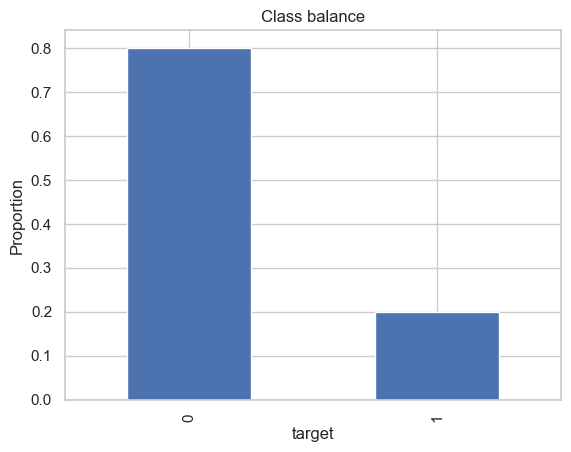

target
0    1076751
1     268599
Name: count, dtype: int64


In [5]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()
df['target'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
target_col = 'target'

df[target_col].value_counts(normalize=True).plot(kind='bar', title='Class balance')
plt.ylabel('Proportion')
plt.show()
print(df[target_col].value_counts())

**Interview note:** classic imbalanced classification — defaults are the minority class (~20%). This is *why* accuracy alone is misleading later, and why SMOTE + precision/recall/ROC-AUC/PR-AUC matter more than a single accuracy number.

## 3. EDA

In [6]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

emp_length    0.058361
revol_util    0.000637
dti           0.000278
dtype: float64

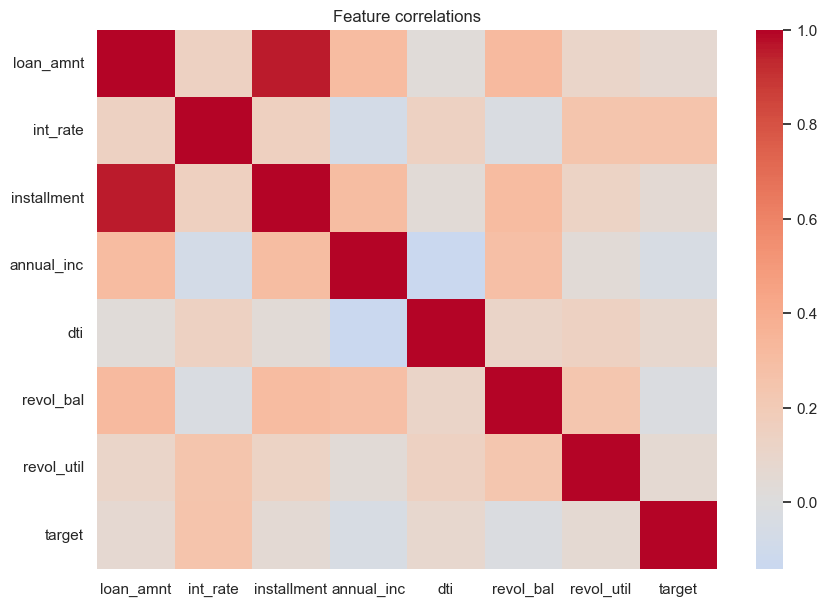

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Feature correlations')
plt.show()

## 4. Feature engineering

In [8]:
df_fe = engineer_features(df)
df_fe = handle_missing(df_fe)
df_fe.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,revol_bal,revol_util,target
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,5.91,2765.0,29.7,0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,16.06,21470.0,19.2,0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,10.78,7869.0,56.2,0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,major_purchase,25.37,21929.0,64.5,0
5,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,debt_consolidation,10.20,8822.0,68.4,0


## 5. Encode categoricals

In [9]:
df_encoded = encode_categoricals(df_fe)
df_encoded.shape

(1345350, 220)

## 6. Remove leakage and low-value columns

**Interview note — mention this proactively.** `loan_status_*` columns directly encode the target — training on them lets the model read the answer instead of learning real risk patterns. `issue_d_*` explodes into ~200 near-useless month/year dummy columns. Both dropped here.

In [10]:
cols_to_drop = [c for c in df_encoded.columns if c.startswith('loan_status_')] + \
               [c for c in df_encoded.columns if c.startswith('issue_d_')]

X = df_encoded.drop(columns=[target_col] + cols_to_drop)
y = df_encoded[target_col]
X.shape

(1345350, 79)

## 7. Train/test split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((1076280, 79), (269070, 79))

## 8. Handle class imbalance (SMOTE)

**Interview note:** SMOTE is applied only to the training set — the test set stays naturally imbalanced, since we want to evaluate on realistic data.

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
y_train_sm.value_counts()

/Users/krishnandanpandit/Desktop/credit-risk-prediction/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


target
0    861401
1    861401
Name: count, dtype: int64

## 9. Train and compare models

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression (baseline)': LogisticRegression(max_iter=2000),
    'Logistic Regression (L1 / Lasso-style)': LogisticRegression(
        penalty='l1', solver='liblinear', max_iter=2000
    ),
    'Logistic Regression (L2 / Ridge-style)': LogisticRegression(
        penalty='l2', max_iter=2000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, class_weight='balanced'
    ),
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc
    predictions[name] = y_pred
    probabilities[name] = y_proba
    print(f'--- {name} (ROC-AUC: {auc:.3f}) ---')
    print(classification_report(y_test, y_pred, digits=3))

/Users/krishnandanpandit/Desktop/credit-risk-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression (baseline) (ROC-AUC: 0.607) ---
              precision    recall  f1-score   support

           0      0.822     0.864     0.842    215350
           1      0.315     0.252     0.280     53720

    accuracy                          0.741    269070
   macro avg      0.569     0.558     0.561    269070
weighted avg      0.721     0.741     0.730    269070

--- Logistic Regression (L1 / Lasso-style) (ROC-AUC: 0.702) ---
              precision    recall  f1-score   support

           0      0.808     0.985     0.888    215350
           1      0.523     0.064     0.115     53720

    accuracy                          0.801    269070
   macro avg      0.666     0.525     0.501    269070
weighted avg      0.751     0.801     0.734    269070



/Users/krishnandanpandit/Desktop/credit-risk-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression (L2 / Ridge-style) (ROC-AUC: 0.607) ---
              precision    recall  f1-score   support

           0      0.822     0.864     0.842    215350
           1      0.315     0.252     0.280     53720

    accuracy                          0.741    269070
   macro avg      0.569     0.558     0.561    269070
weighted avg      0.721     0.741     0.730    269070

--- Random Forest (ROC-AUC: 0.693) ---
              precision    recall  f1-score   support

           0      0.843     0.844     0.843    215350
           1      0.370     0.368     0.369     53720

    accuracy                          0.749    269070
   macro avg      0.606     0.606     0.606    269070
weighted avg      0.748     0.749     0.748    269070



## 10. Confusion matrices — all models side by side

**Interview note:** bottom-left = false negatives (missed defaults — the expensive mistake for a lender). Top-right = false positives (false alarms — cheaper, but still a cost).

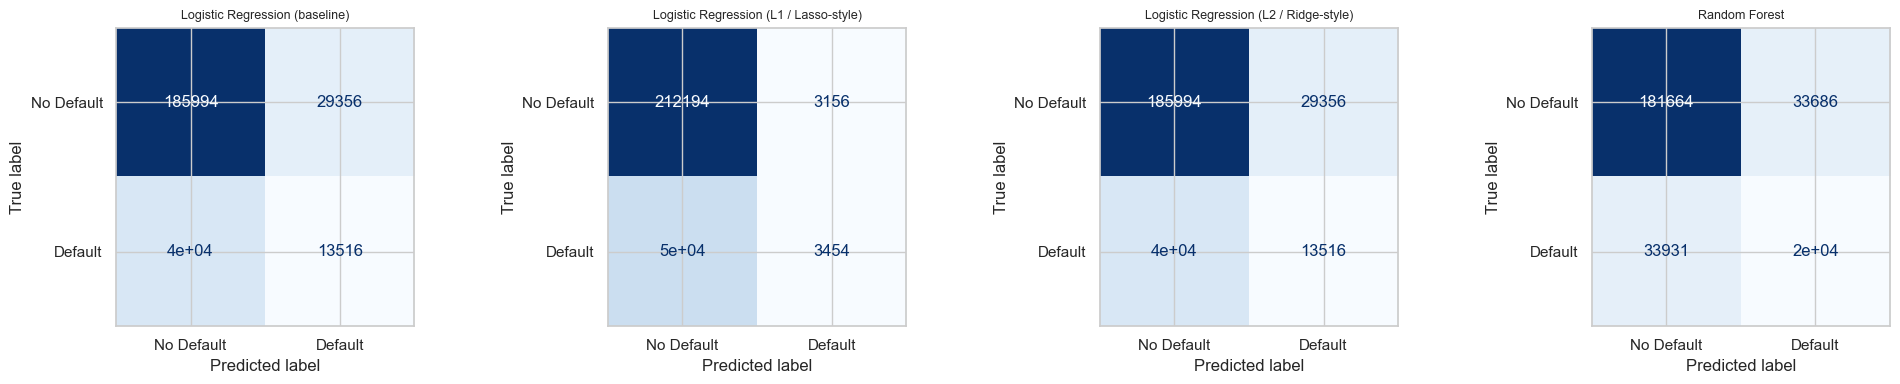

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

## 11. Precision / Recall / F1 / ROC-AUC — full comparison

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_table = []
for name, model in models.items():
    y_pred = predictions[name]
    metrics_table.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': results[name],
    })

metrics_df = pd.DataFrame(metrics_table).set_index('Model')
metrics_df

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression (baseline),0.315264,0.251601,0.279858,0.607413
Logistic Regression (L1 / Lasso-style),0.522542,0.064296,0.114504,0.702325
Logistic Regression (L2 / Ridge-style),0.315264,0.251601,0.279858,0.607413
Random Forest,0.370061,0.368373,0.369215,0.692706


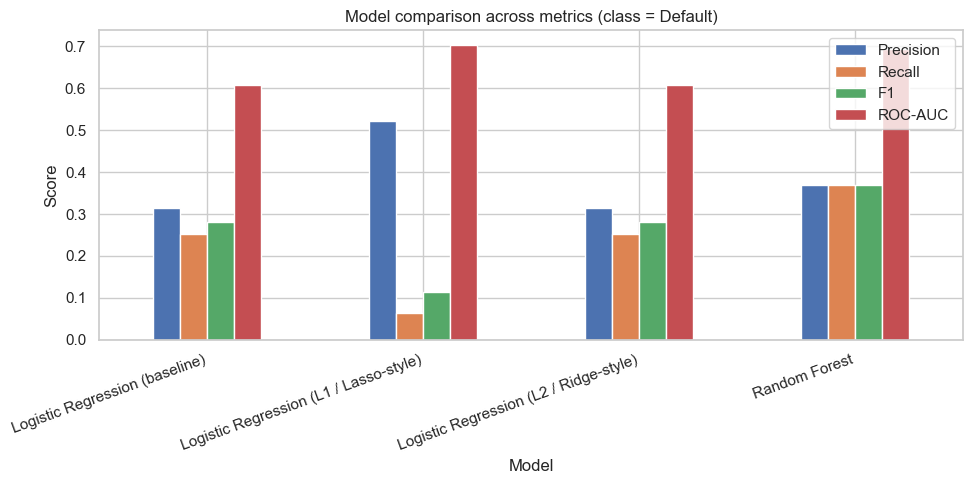

In [16]:
metrics_df[['Precision', 'Recall', 'F1', 'ROC-AUC']].plot(kind='bar', figsize=(10, 5))
plt.title('Model comparison across metrics (class = Default)')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Interview note — key chart.** A model can have the best ROC-AUC and still be nearly useless at the deployed threshold if its recall for the minority class is low (this is exactly what happened with L1 in this project — highest ROC-AUC, but recall collapsed to ~6%). Always check this table alongside ROC-AUC, never trust AUC alone.

## 12. ROC Curve — all models

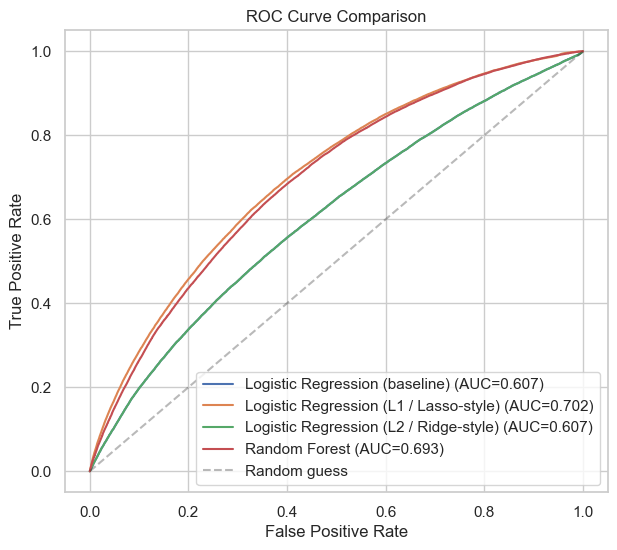

In [17]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={results[name]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 13. Precision-Recall Curve — all models

**Interview note:** ROC-AUC can look deceptively good on imbalanced data because it's inflated by the large number of true negatives. The Precision-Recall curve is often the more honest picture when the positive class is a small minority.

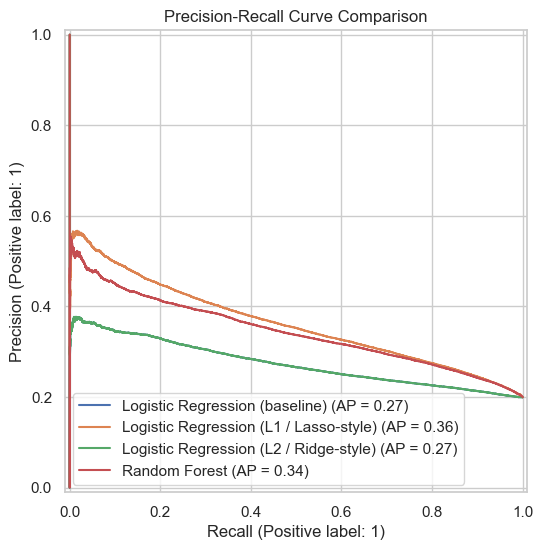

In [18]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
plt.title('Precision-Recall Curve Comparison')
plt.show()

## 14. Threshold tuning

`.predict()` uses a fixed 0.5 cutoff. A high ROC-AUC only means a model *ranks* applicants well — it says nothing about whether 0.5 is the right cutoff for your business problem.

In [19]:
from sklearn.metrics import recall_score, precision_score, f1_score

threshold_rows = []
for name, y_proba in probabilities.items():
    for t in [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]:
        y_pred_t = (y_proba >= t).astype(int)
        threshold_rows.append({
            'Model': name,
            'Threshold': t,
            'Recall': recall_score(y_test, y_pred_t),
            'Precision': precision_score(y_test, y_pred_t),
            'F1': f1_score(y_test, y_pred_t),
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Model,Threshold,Recall,Precision,F1
0,Logistic Regression (baseline),0.50,0.251601,0.315264,0.279858
1,Logistic Regression (baseline),0.40,0.373846,0.288868,0.325909
2,Logistic Regression (baseline),0.30,0.527699,0.261547,0.349746
3,Logistic Regression (baseline),0.20,0.694471,0.238405,0.354957
4,Logistic Regression (baseline),0.15,0.770309,0.229198,0.353281
5,Logistic Regression (baseline),0.10,0.857688,0.219188,0.349148
6,Logistic Regression (L1 / Lasso-style),0.50,0.064296,0.522542,0.114504
7,Logistic Regression (L1 / Lasso-style),0.40,0.193671,0.451504,0.271068
8,Logistic Regression (L1 / Lasso-style),0.30,0.405808,0.377169,0.390965
9,Logistic Regression (L1 / Lasso-style),0.20,0.697301,0.302401,0.421855


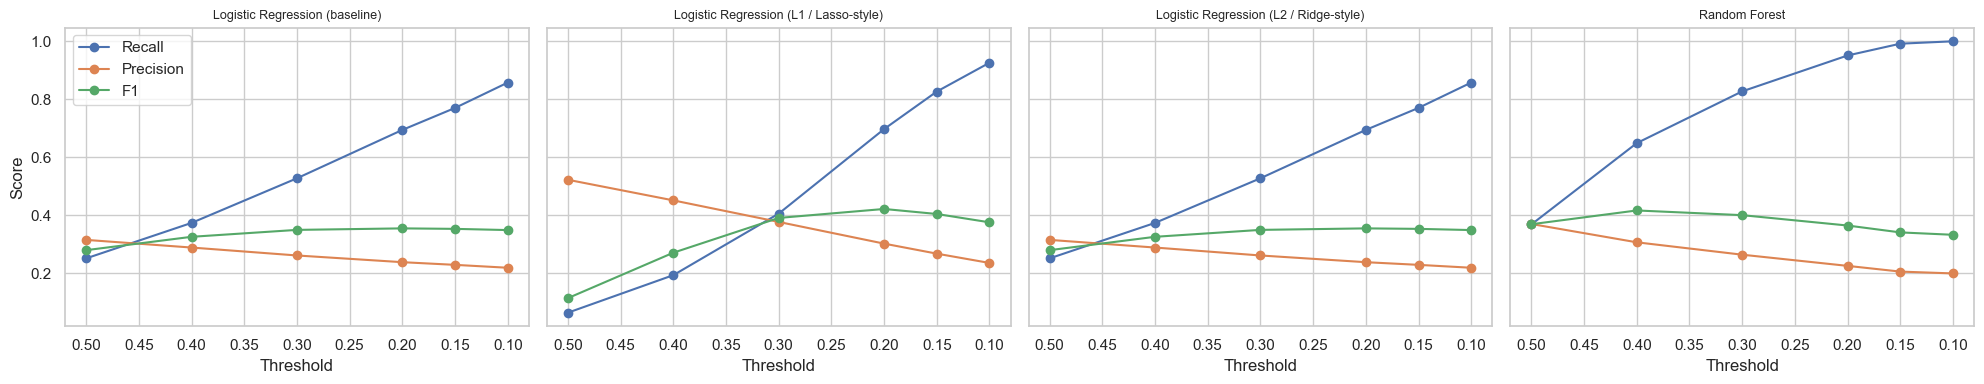

In [20]:
fig, axes = plt.subplots(1, len(models), figsize=(20, 4), sharey=True)
for ax, name in zip(axes, models.keys()):
    sub = threshold_df[threshold_df['Model'] == name]
    ax.plot(sub['Threshold'], sub['Recall'], marker='o', label='Recall')
    ax.plot(sub['Threshold'], sub['Precision'], marker='o', label='Precision')
    ax.plot(sub['Threshold'], sub['F1'], marker='o', label='F1')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Threshold')
    ax.invert_xaxis()
axes[0].set_ylabel('Score')
axes[0].legend()
plt.tight_layout()
plt.show()

**How to read this:** lowering the threshold generally increases recall at the cost of precision. Pick the threshold where recall reaches an acceptable level without precision collapsing too far — it's a business tradeoff, not a single "correct" answer.

## 15. Cross-validation — is the ROC-AUC number stable?

**Interview note — important, and a good story if asked about it.** Cross-validating on data that's *already been SMOTE'd* leaks information between folds — synthetic points in a validation fold can be interpolated from real points sitting in a different training fold, artificially inflating the score. The fix: put SMOTE **inside** an `imblearn` Pipeline, so it's refit fresh within each fold using only that fold's training data. This uses `X_train`/`y_train` (the *pre*-SMOTE data), not `X_train_sm`. Also uses a subsample and capped parallelism to keep it light on a laptop.

In [21]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score

sample_size = 50000
X_cv_sample = X_train.sample(sample_size, random_state=42)
y_cv_sample = y_train.loc[X_cv_sample.index]

cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, class_weight='balanced'
    )),
])

cv_scores = cross_val_score(
    cv_pipeline, X_cv_sample, y_cv_sample,
    cv=3, scoring='roc_auc', n_jobs=2
)
print(f'Random Forest (SMOTE inside CV folds): CV ROC-AUC = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

/Users/krishnandanpandit/Desktop/credit-risk-prediction/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/krishnandanpandit/Desktop/credit-risk-prediction/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/krishnandanpandit/Desktop/credit-risk-prediction/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is p

Random Forest (SMOTE inside CV folds): CV ROC-AUC = 0.690 ± 0.002


**Sanity check:** this number should land close to your test-set ROC-AUC (~0.69). If it's dramatically higher (like ~0.90), SMOTE leakage has crept back in somewhere — double check `X_cv_sample` comes from `X_train`, not `X_train_sm`.

## 16. Feature importance (Random Forest) vs SHAP

**Interview note:** feature importance (below) is *global* — which features matter most across all predictions on average. SHAP (later) is *local* — why one specific prediction came out the way it did. They can disagree, and knowing why (tree importance can be biased toward high-cardinality/continuous features; SHAP is more theoretically grounded and consistent) is a strong answer if asked the difference.

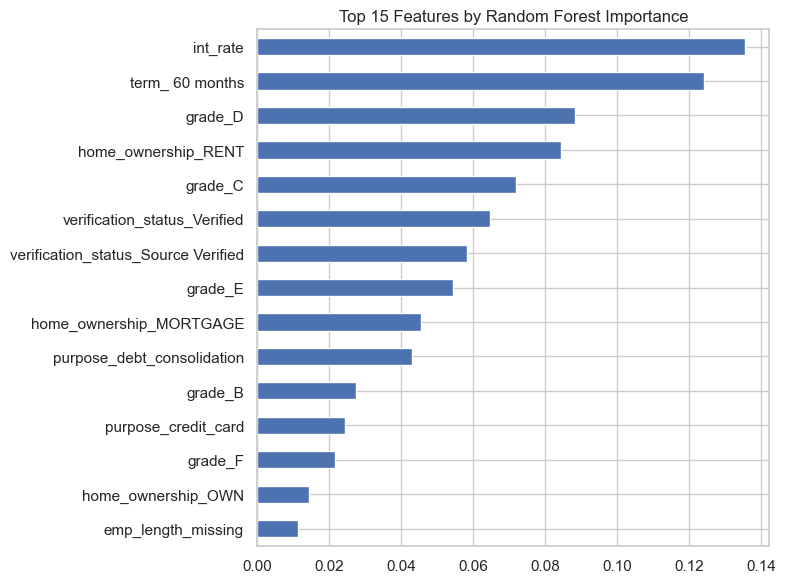

In [22]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X_train_sm.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Features by Random Forest Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 17. Final model + threshold selection

- **Chosen model:** Random Forest (n_estimators=300, max_depth=8, class_weight='balanced')
- **Chosen threshold:** 0.5 (default)
- **ROC-AUC (test):** 0.693
- **ROC-AUC (5-fold... 3-fold CV, leak-free):** _fill in from section 15's output_
- **Recall / Precision / F1 at chosen threshold:** 0.368 / 0.370 / 0.369
- **Why this model over the others:** L1 Logistic Regression had a marginally higher ROC-AUC (0.702 vs 0.693), but its recall collapsed to 6.5% at the standard threshold — meaning it would catch only a small fraction of actual defaults in practice. Random Forest offers a far more usable balance (36.8% recall) at nearly the same ROC-AUC, making it the more practical choice for a lending use case where missed defaults are costly.
- **What I'd try next with more time:** proper cost-sensitive threshold selection using real cost estimates for false negatives vs false positives, hyperparameter tuning via GridSearchCV, and testing XGBoost/LightGBM as an alternative to Random Forest.

In [23]:
best_model_name = 'Random Forest'
chosen_threshold = 0.5

best_model = models[best_model_name]
print('Selected model:', best_model_name)
print('Selected threshold:', chosen_threshold)

Selected model: Random Forest
Selected threshold: 0.5


## 18. Business impact estimate

**Interview note:** this is the piece almost no student portfolio includes. Translating the confusion matrix into an approximate dollar figure connects your ML metrics to an actual business outcome. Treat this as a rough, order-of-magnitude estimate, not a precise financial model — say so explicitly if asked.

In [24]:
avg_loan_amount = df['loan_amnt'].mean()

y_pred_final = (probabilities[best_model_name] >= chosen_threshold).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print(f'True positives (caught defaults): {tp}')
print(f'False negatives (missed defaults): {fn}')
print(f'False positives (false alarms): {fp}')
print(f'Average loan amount: ${avg_loan_amount:,.0f}')
print(f'Estimated capital at risk from missed defaults: ${fn * avg_loan_amount:,.0f}')
print(f'Estimated capital correctly flagged: ${tp * avg_loan_amount:,.0f}')

True positives (caught defaults): 19789
False negatives (missed defaults): 33931
False positives (false alarms): 33686
Average loan amount: $14,420
Estimated capital at risk from missed defaults: $489,284,000
Estimated capital correctly flagged: $285,356,785


## 19. Explainability with SHAP

Cast to float first — avoids a dtype bug in some shap/numpy version combinations. Uses a genuine background sample so SHAP values reflect a real deviation from baseline, not a comparison against itself.

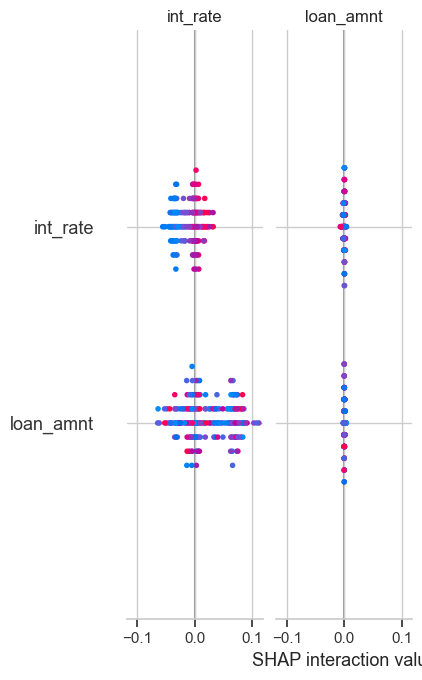

In [25]:
import shap

X_train_clean = X_train_sm.astype(float)
X_test_clean = X_test[:200].astype(float)

explainer = shap.Explainer(best_model, X_train_clean)
shap_values = explainer(X_test_clean)

shap.summary_plot(shap_values, X_test_clean)

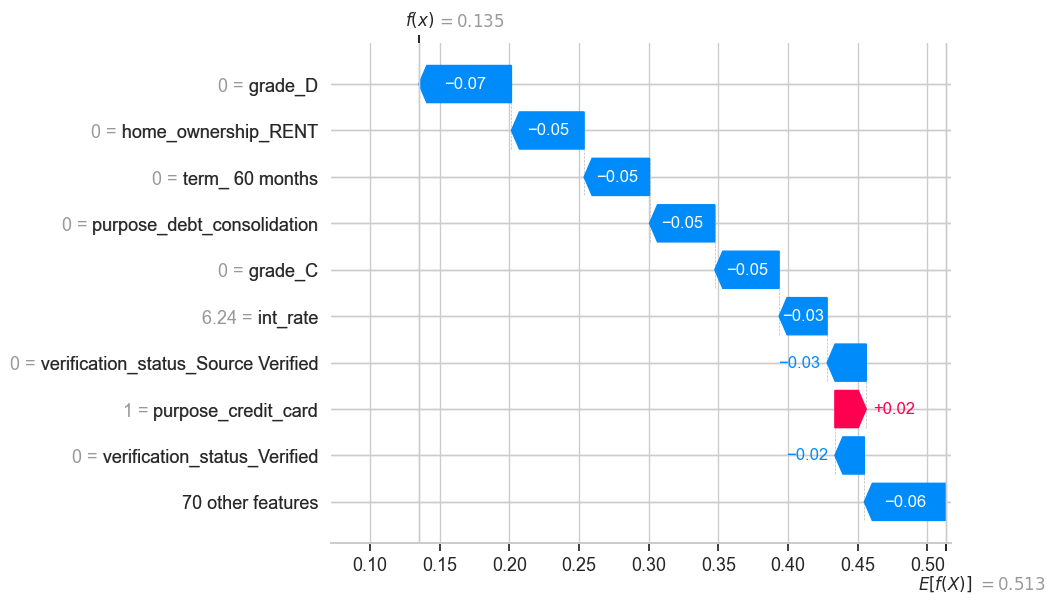

In [29]:
# Individual prediction explanations — check a few different applicants
#shap.plots.waterfall(shap_values[0])
shap.plots.waterfall(shap_values[0, :, 1])

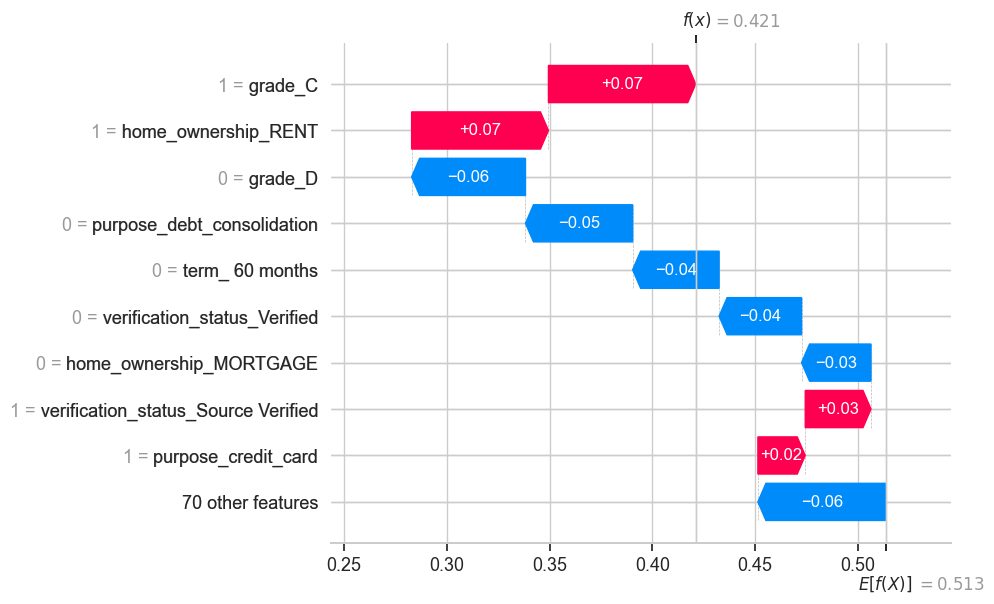

In [31]:
shap.plots.waterfall(shap_values[5, :, 1])

## 20. Save model + background sample for the Streamlit app

In [32]:
import joblib

joblib.dump(best_model, '../model.pkl')

background_sample = X_train_sm.sample(100, random_state=42).astype(float)
joblib.dump(background_sample, '../background.pkl')

print('Saved model.pkl and background.pkl')
print('Feature columns (copy into src/app.py FEATURE_COLUMNS if changed):')
list(X_train_sm.columns)

Saved model.pkl and background.pkl
Feature columns (copy into src/app.py FEATURE_COLUMNS if changed):


['loan_amnt',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'revol_bal',
 'revol_util',
 'term_ 60 months',
 'grade_B',
 'grade_C',
 'grade_D',
 'grade_E',
 'grade_F',
 'grade_G',
 'sub_grade_A2',
 'sub_grade_A3',
 'sub_grade_A4',
 'sub_grade_A5',
 'sub_grade_B1',
 'sub_grade_B2',
 'sub_grade_B3',
 'sub_grade_B4',
 'sub_grade_B5',
 'sub_grade_C1',
 'sub_grade_C2',
 'sub_grade_C3',
 'sub_grade_C4',
 'sub_grade_C5',
 'sub_grade_D1',
 'sub_grade_D2',
 'sub_grade_D3',
 'sub_grade_D4',
 'sub_grade_D5',
 'sub_grade_E1',
 'sub_grade_E2',
 'sub_grade_E3',
 'sub_grade_E4',
 'sub_grade_E5',
 'sub_grade_F1',
 'sub_grade_F2',
 'sub_grade_F3',
 'sub_grade_F4',
 'sub_grade_F5',
 'sub_grade_G1',
 'sub_grade_G2',
 'sub_grade_G3',
 'sub_grade_G4',
 'sub_grade_G5',
 'emp_length_10+ years',
 'emp_length_2 years',
 'emp_length_3 years',
 'emp_length_4 years',
 'emp_length_5 years',
 'emp_length_6 years',
 'emp_length_7 years',
 'emp_length_8 years',
 'emp_length_9 years',
 'emp_length_< 1 year',
 '

## 21. Model card (for README)

- **Problem:** Binary classification — will a loan default?
- **Data:** LendingClub accepted loans, 2007–2018 — 2,260,701 rows loaded, 1,345,350 kept after filtering to known outcomes (1,076,751 no-default / 268,599 default)
- **Class balance:** ~80/20 (non-default/default), handled via SMOTE
- **Best model:** Random Forest (n_estimators=300, max_depth=8, class_weight='balanced')
- **Performance:** ROC-AUC 0.693 (test), _fill in CV number from section 15_, Recall 0.368, Precision 0.370 (at threshold 0.5)
- **Key insight:** Chose Random Forest over a higher-AUC alternative (L1 Logistic Regression) because the latter's recall collapsed to ~6.5% at deployment threshold — a reminder that ROC-AUC alone can be misleading on imbalanced data. Also caught and fixed a SMOTE/cross-validation leakage bug where validating on already-resampled data inflated the CV score.
- **Limitation:** Only trained on approved applicants — LendingClub's own approval decisions aren't modeled, so there's selection bias in the training population.